In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings
from tqdm import tqdm

In [41]:
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.measure import regionprops, label as sk_label
from skimage.morphology import opening, closing, disk
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed, clear_border
from skimage import img_as_ubyte

In [42]:
from scipy import ndimage, stats
from scipy.signal import convolve2d

In [43]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import KernelPCA, PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score)
from sklearn.pipeline import Pipeline

In [44]:
#### Chargement des données

BASE_DIR = "/Users/agshayn/Desktop/cours/2A/IMA/4IM05/projet_kaggle/wbc-classification/data/raw/IMA205-challenge 2"  # Racine de votre dataset
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")
TRAIN_CSV = os.path.join(BASE_DIR, "train_metadata.csv")
TEST_CSV = os.path.join(BASE_DIR, "test_metadata.csv")
SAMPLE_SUB = os.path.join(BASE_DIR, "sample_submission.csv")

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Train metadata shape : {train_df.shape}")
print(f"Test metadata shape  : {test_df.shape}")
print(f"\nColonnes train : {train_df.columns.tolist()}")
print(f"\nDistribution des classes :\n{train_df.iloc[:, 1].value_counts()}")
print(f"\nNombre de classes : {train_df.iloc[:, 1].nunique()}")

Train metadata shape : (28901, 2)
Test metadata shape  : (9634, 1)

Colonnes train : ['ID', 'label']

Distribution des classes :
label
SNE    13015
LY      8101
MO      2746
BL      2012
EO       861
MY       441
BA       415
BNE      391
VLY      366
MMY      360
PMY      114
PC        68
PLY       11
Name: count, dtype: int64

Nombre de classes : 13


In [45]:
### Identification
id_col = train_df.columns[0]
label_col = train_df.columns[1]
print(f"Colonne ID    : '{id_col}'")
print(f"Colonne Label : '{label_col}'")

### Encoder les labels
le = LabelEncoder()
train_df['label_encoded'] = le.fit_transform(train_df[label_col])
class_names = le.classes_
print(f"\nClasses : {class_names}")
print(id_col)

Colonne ID    : 'ID'
Colonne Label : 'label'

Classes : ['BA' 'BL' 'BNE' 'EO' 'LY' 'MMY' 'MO' 'MY' 'PC' 'PLY' 'PMY' 'SNE' 'VLY']
ID


In [46]:
print(train_df[label_col].value_counts())

label
SNE    13015
LY      8101
MO      2746
BL      2012
EO       861
MY       441
BA       415
BNE      391
VLY      366
MMY      360
PMY      114
PC        68
PLY       11
Name: count, dtype: int64


Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb


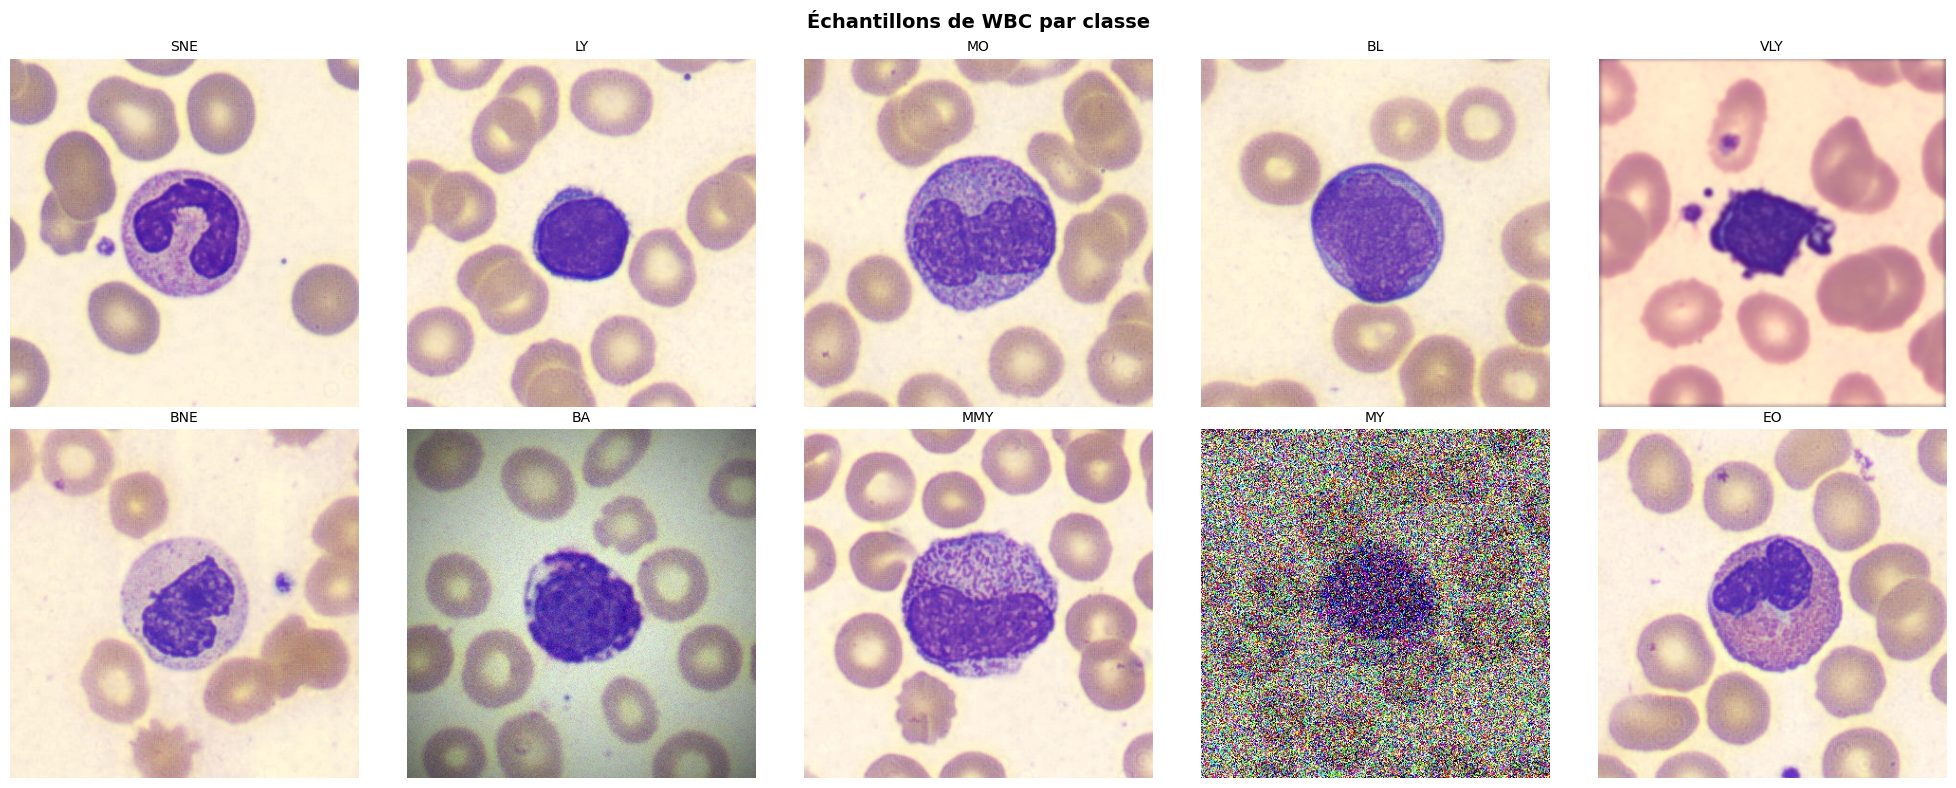

In [47]:

#### Visualisation d'Échantillons

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

unique_labels = train_df[label_col].unique()[:10]
for i, lbl in enumerate(unique_labels):
    if i >= 10:
        break
    sample = train_df[train_df[label_col] == lbl].iloc[0]
    img_path = os.path.join(TRAIN_DIR, f"{sample[id_col]}")
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f"{lbl}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Échantillons de WBC par classe", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Corrupt JPEG data: 27 extraneous bytes before marker 0xdb


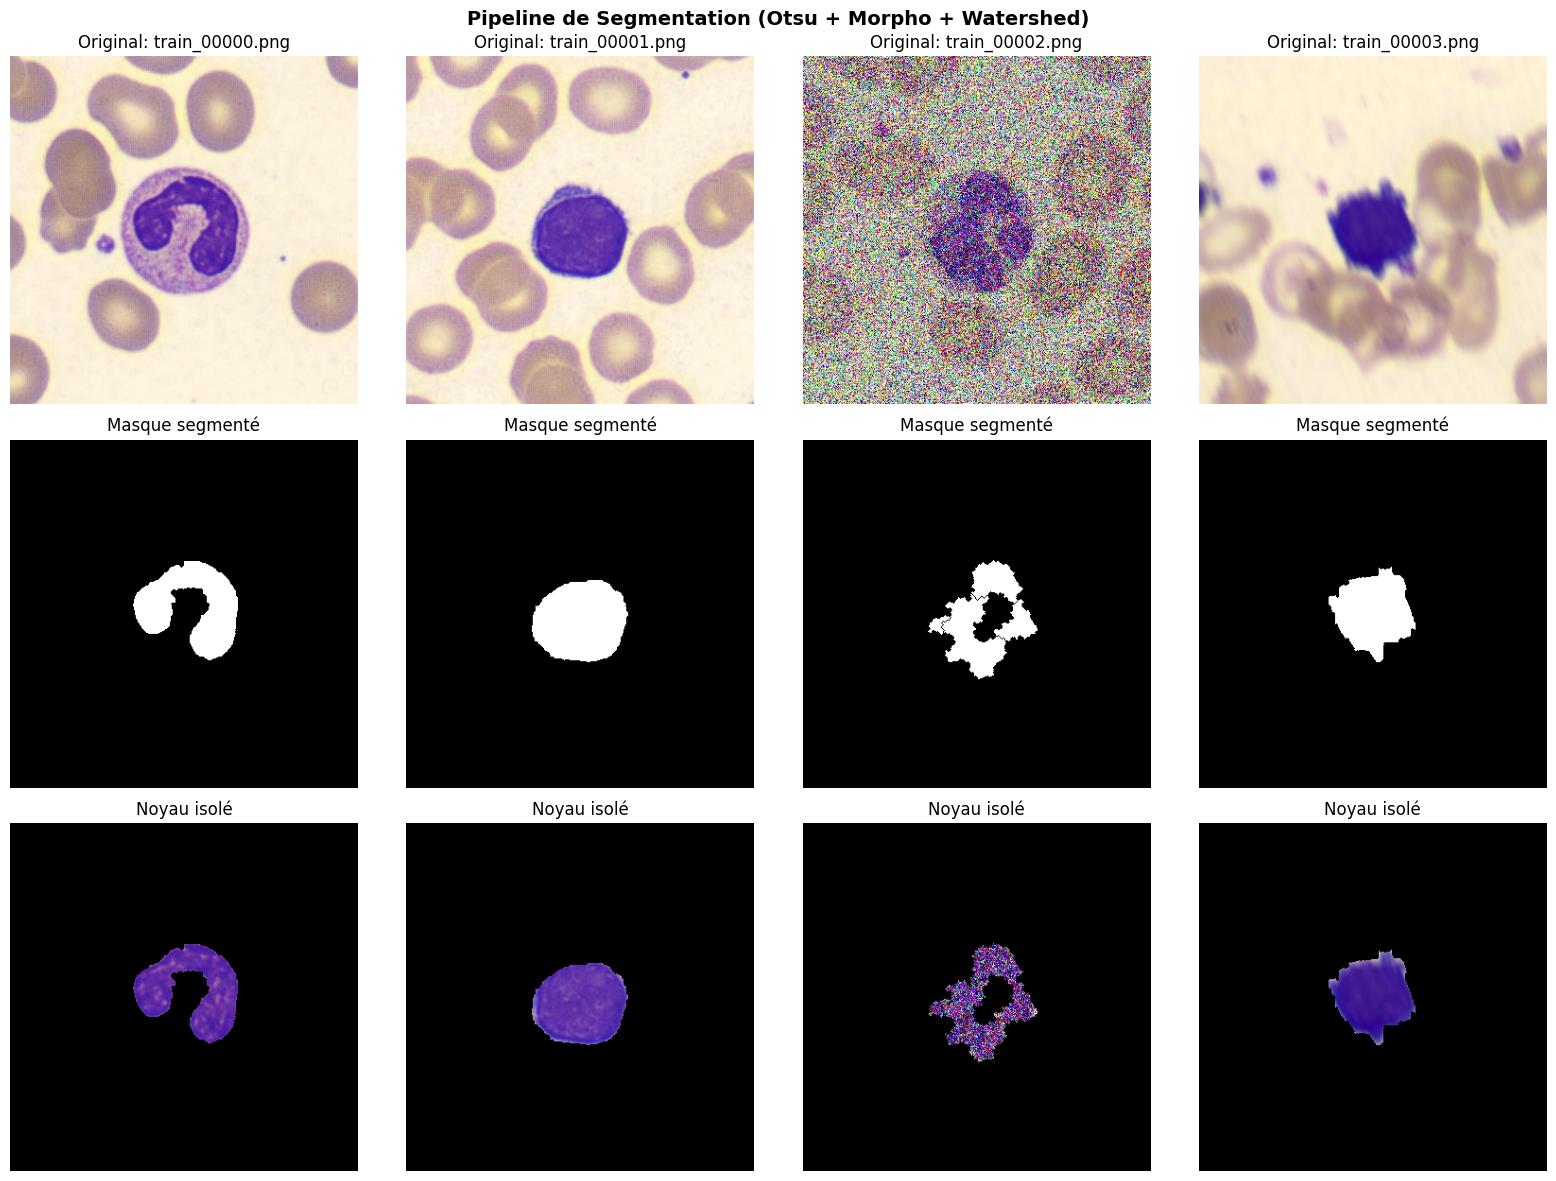

In [48]:
def segment_wbc(img_bgr):
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    h, s, v = cv2.split(img_hsv)
    r = img_bgr[:, :, 2].astype(np.float32)
    g = img_bgr[:, :, 1].astype(np.float32)
    b = img_bgr[:, :, 0].astype(np.float32)
    purple_score_map = (r + b - 2 * g).clip(0, 255).astype(np.uint8)

    ### Img bruité
    noise_level = np.std(img_gray)
    is_noisy = noise_level > 40  

    if is_noisy:
        thresh_s = threshold_otsu(s)
        _, mask = cv2.threshold(s, thresh_s, 255, cv2.THRESH_BINARY)
        kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small, iterations=2)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)

    else:
        lower_purple = np.array([100, 40, 30])
        upper_purple = np.array([175, 255, 200])
        mask_hsv = cv2.inRange(img_hsv, lower_purple, upper_purple)
        mask_not_white = (v < 210).astype(np.uint8) * 255
        thresh_val = threshold_otsu(purple_score_map)
        _, mask_purple = cv2.threshold(purple_score_map, thresh_val, 255, cv2.THRESH_BINARY)
        mask_purple = cv2.bitwise_and(mask_purple, mask_not_white)

        mask = cv2.bitwise_or(mask_hsv, mask_purple)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        best_contour = None
        best_score = -1

        for cnt in contours:
            area_cnt = cv2.contourArea(cnt)
            if area_cnt < 200:
                continue

            tmp_mask = np.zeros_like(img_gray)
            cv2.drawContours(tmp_mask, [cnt], -1, 255, -1)
            mean_purple = np.mean(purple_score_map[tmp_mask > 0])
            mean_sat = np.mean(s[tmp_mask > 0])
            combined_score = mean_purple + mean_sat

            if combined_score > best_score:
                best_score = combined_score
                best_contour = cnt

        if best_contour is not None:
            mask_filled = np.zeros_like(mask)
            cv2.drawContours(mask_filled, [best_contour], -1, 255, -1)
            mask = mask_filled
        else:
            _, mask = cv2.threshold(img_gray, threshold_otsu(img_gray), 255, cv2.THRESH_BINARY_INV)
    else:
        _, mask = cv2.threshold(img_gray, threshold_otsu(img_gray), 255, cv2.THRESH_BINARY_INV)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    area = np.sum(mask > 0)
    if area > 500:
        dist_transform = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
        _, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)

        sure_bg = cv2.dilate(mask, kernel, iterations=3)
        unknown = cv2.subtract(sure_bg, sure_fg)

        _, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1
        markers[unknown == 255] = 0

        markers_ws = cv2.watershed(img_bgr, markers)
        mask_final = np.zeros_like(img_gray)
        mask_final[markers_ws > 1] = 255

        if np.sum(mask_final > 0) < area * 0.3:
            mask_final = mask
    else:
        mask_final = mask

    nucleus_region = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_final)
    return mask_final, nucleus_region


fig, axes = plt.subplots(3, 4, figsize=(16, 12))
sample_ids = train_df[id_col].values[:4]

for i, sid in enumerate(sample_ids):
    img_path = os.path.join(TRAIN_DIR, f"{sid}")
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    mask, nucleus = segment_wbc(img)
    
    axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Original: {sid}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title("Masque segmenté")
    axes[1, i].axis('off')
    
    axes[2, i].imshow(cv2.cvtColor(nucleus, cv2.COLOR_BGR2RGB))
    axes[2, i].set_title("Noyau isolé")
    axes[2, i].axis('off')

plt.suptitle("Pipeline de Segmentation (Otsu + Morpho + Watershed)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
### Features Géométriques

def extract_geometric_features(mask):
    features = {}
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        keys = ['area', 'perimeter', 'equiv_radius', 'circularity', 
                'eccentricity', 'compactness', 'aspect_ratio', 
                'solidity', 'extent', 'convex_area']
        return {k: 0.0 for k in keys}
    
    cnt = max(contours, key=cv2.contourArea)
    
    ### Aire
    area = cv2.contourArea(cnt)
    features['area'] = area
    
    ### Périmètre
    perimeter = cv2.arcLength(cnt, True)
    features['perimeter'] = perimeter
    
    ### Rayon équivalent
    features['equiv_radius'] = np.sqrt(area / np.pi) if area > 0 else 0
    
    ### Circularité 
    features['circularity'] = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    
    ### Excentricité 
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (cx, cy), (MA, ma), angle = ellipse
        a = max(MA, ma) / 2
        b = min(MA, ma) / 2
        features['eccentricity'] = np.sqrt(1 - (b**2 / a**2)) if a > 0 else 0
        features['aspect_ratio'] = MA / ma if ma > 0 else 0
    else:
        features['eccentricity'] = 0
        features['aspect_ratio'] = 0
    
    ### Compacité = Périmètre² / Aire
    features['compactness'] = (perimeter ** 2) / area if area > 0 else 0
    
    ### Solidité = Aire / Aire convexe
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    features['solidity'] = area / hull_area if hull_area > 0 else 0
    features['convex_area'] = hull_area
    
    # Étendue = Aire / Aire du bounding rect
    x, y, w, h = cv2.boundingRect(cnt)
    rect_area = w * h
    features['extent'] = area / rect_area if rect_area > 0 else 0
    
    return features

In [50]:
### Features textures

def extract_lbp_features(gray_img, mask, n_points=24, radius=3, n_bins=26):
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')
    lbp_masked = lbp[mask > 0]
    
    if len(lbp_masked) == 0:
        return {f'lbp_bin_{i}': 0.0 for i in range(n_bins)}
    
    hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_points + 2), density=True)
    features = {f'lbp_bin_{i}': hist[i] for i in range(len(hist))}
    
    features['lbp_mean'] = np.mean(lbp_masked)
    features['lbp_std'] = np.std(lbp_masked)
    features['lbp_energy'] = np.sum(hist ** 2)
    features['lbp_entropy'] = -np.sum(hist[hist > 0] * np.log2(hist[hist > 0]))
    
    return features


def extract_ldp_features(gray_img, mask):

    kirsch_masks = [
        np.array([[-3, -3, 5], [-3, 0, 5], [-3, -3, 5]]),   
        np.array([[-3, 5, 5], [-3, 0, 5], [-3, -3, -3]]),    
        np.array([[5, 5, 5], [-3, 0, -3], [-3, -3, -3]]),     
        np.array([[5, 5, -3], [5, 0, -3], [-3, -3, -3]]),     
        np.array([[5, -3, -3], [5, 0, -3], [5, -3, -3]]),     
        np.array([[-3, -3, -3], [5, 0, -3], [5, 5, -3]]),     
        np.array([[-3, -3, -3], [-3, 0, -3], [5, 5, 5]]),     
        np.array([[-3, -3, -3], [-3, 0, 5], [-3, 5, 5]])      
    ]
    
    responses = []
    for km in kirsch_masks:
        resp = convolve2d(gray_img.astype(np.float64), km, mode='same', boundary='symm')
        responses.append(np.abs(resp))
    
    responses = np.array(responses)
    
    k = 3
    sorted_indices = np.argsort(responses, axis=0)[::-1]
    
    ldp_code = np.zeros(gray_img.shape, dtype=np.uint8)
    for i in range(k):
        direction = sorted_indices[i]
        ldp_code += (1 << direction).astype(np.uint8)
    
    ldp_masked = ldp_code[mask > 0]
    
    if len(ldp_masked) == 0:
        return {f'ldp_bin_{i}': 0.0 for i in range(56)}
    
    hist, _ = np.histogram(ldp_masked, bins=56, range=(0, 256), density=True)
    
    features = {f'ldp_bin_{i}': hist[i] for i in range(len(hist))}
    features['ldp_mean'] = np.mean(ldp_masked)
    features['ldp_std'] = np.std(ldp_masked)
    features['ldp_entropy'] = -np.sum(hist[hist > 0] * np.log2(hist[hist > 0]))
    
    return features


def extract_pricolbp_features(gray_img, mask, radius=2):
    n_points = 8
    
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')
    n_patterns = n_points + 2  
    
    rows, cols = gray_img.shape
    co_matrix = np.zeros((n_patterns, n_patterns), dtype=np.float64)
    
    for angle_idx in range(n_points // 2):
        angle1 = 2 * np.pi * angle_idx / n_points
        angle2 = angle1 + np.pi
        
        dx1, dy1 = int(round(radius * np.cos(angle1))), int(round(radius * np.sin(angle1)))
        dx2, dy2 = int(round(radius * np.cos(angle2))), int(round(radius * np.sin(angle2)))
        
        for r in range(radius, rows - radius):
            for c in range(radius, cols - radius):
                if mask[r, c] == 0:
                    continue
                p1 = int(lbp[r + dy1, c + dx1]) if 0 <= r+dy1 < rows and 0 <= c+dx1 < cols else 0
                p2 = int(lbp[r + dy2, c + dx2]) if 0 <= r+dy2 < rows and 0 <= c+dx2 < cols else 0
                p1 = min(p1, n_patterns - 1)
                p2 = min(p2, n_patterns - 1)
                co_matrix[p1, p2] += 1
    
    total = co_matrix.sum()
    if total > 0:
        co_matrix /= total
    
    features = {}
    features['pricolbp_energy'] = np.sum(co_matrix ** 2)
    features['pricolbp_entropy'] = -np.sum(co_matrix[co_matrix > 0] * np.log2(co_matrix[co_matrix > 0]))
    features['pricolbp_contrast'] = sum(
        co_matrix[i, j] * (i - j) ** 2
        for i in range(n_patterns)
        for j in range(n_patterns)
    )
    features['pricolbp_homogeneity'] = sum(
        co_matrix[i, j] / (1 + abs(i - j))
        for i in range(n_patterns)
        for j in range(n_patterns)
    )
    
    upper_tri = co_matrix[np.triu_indices(n_patterns)]
    for idx, val in enumerate(upper_tri[:20]):  # Limiter à 20
        features[f'pricolbp_co_{idx}'] = val
    
    return features

In [51]:
### Features couleurs

def extract_color_features(img_bgr, mask):
    features = {}
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    channel_names_rgb = ['red', 'green', 'blue']
    channel_names_hsv = ['hue', 'saturation', 'value']
    
    for img_space, ch_names in [(img_rgb, channel_names_rgb), (img_hsv, channel_names_hsv)]:
        for ch_idx, ch_name in enumerate(ch_names):
            channel = img_space[:, :, ch_idx]
            masked_pixels = channel[mask > 0]
            
            if len(masked_pixels) == 0:
                features[f'{ch_name}_mean'] = 0
                features[f'{ch_name}_std'] = 0
                features[f'{ch_name}_skew'] = 0
                features[f'{ch_name}_kurtosis'] = 0
                features[f'{ch_name}_median'] = 0
                features[f'{ch_name}_min'] = 0
                features[f'{ch_name}_max'] = 0
                continue
            
            features[f'{ch_name}_mean'] = np.mean(masked_pixels)
            features[f'{ch_name}_std'] = np.std(masked_pixels)
            features[f'{ch_name}_skew'] = float(stats.skew(masked_pixels))
            features[f'{ch_name}_kurtosis'] = float(stats.kurtosis(masked_pixels))
            features[f'{ch_name}_median'] = np.median(masked_pixels)
            features[f'{ch_name}_min'] = np.min(masked_pixels)
            features[f'{ch_name}_max'] = np.max(masked_pixels)
    
    mean_r = features.get('red_mean', 1)
    mean_g = features.get('green_mean', 1)
    mean_b = features.get('blue_mean', 1)
    total = mean_r + mean_g + mean_b + 1e-8
    features['ratio_rg'] = mean_r / (mean_g + 1e-8)
    features['ratio_rb'] = mean_r / (mean_b + 1e-8)
    features['ratio_gb'] = mean_g / (mean_b + 1e-8)
    features['norm_r'] = mean_r / total
    features['norm_g'] = mean_g / total
    features['norm_b'] = mean_b / total
    
    return features


In [52]:
### Features invariantes

def extract_dtcwt_features(gray, mask, levels=3):
    features = {}
    
    orientations = [0, 60, 120]
    sigmas = [1, 3]
    frequencies = [0.3, 0.15]
    
    subband_idx = 0
    for sigma, freq in zip(sigmas, frequencies):
        for theta_deg in orientations:
            theta = np.deg2rad(theta_deg)
            kernel_real = cv2.getGaborKernel(
                ksize=(11, 11),  
                sigma=sigma, theta=theta,
                lambd=1.0/freq, gamma=0.5, psi=0
            )
            kernel_imag = cv2.getGaborKernel(
                ksize=(11, 11),
                sigma=sigma, theta=theta,
                lambd=1.0/freq, gamma=0.5, psi=np.pi/2
            )
            resp_real = cv2.filter2D(gray.astype(np.float32), -1, kernel_real)
            resp_imag = cv2.filter2D(gray.astype(np.float32), -1, kernel_imag)
            magnitude = np.sqrt(resp_real**2 + resp_imag**2)
            
            mag_masked = magnitude[mask > 0]
            if len(mag_masked) > 0:
                features[f'dtcwt_mag_mean_{subband_idx}'] = np.mean(mag_masked)
                features[f'dtcwt_mag_std_{subband_idx}'] = np.std(mag_masked)
                features[f'dtcwt_mag_energy_{subband_idx}'] = np.mean(mag_masked ** 2)
            else:
                features[f'dtcwt_mag_mean_{subband_idx}'] = 0
                features[f'dtcwt_mag_std_{subband_idx}'] = 0
                features[f'dtcwt_mag_energy_{subband_idx}'] = 0
            subband_idx += 1
    
    return features


def extract_bispectral_features(gray_img, mask, n_features=15):
    features = {}
    
    masked_img = gray_img.copy().astype(np.float64)
    masked_img[mask == 0] = 0
    
    target_size = 64
    resized = cv2.resize(masked_img, (target_size, target_size))
    
    F = np.fft.fft2(resized)
    F_shifted = np.fft.fftshift(F)
    
    magnitude = np.abs(F_shifted)
    phase = np.angle(F_shifted)
    center = target_size // 2
    
    radii = np.arange(1, center)
    radial_profile = []
    for r in radii:
        angles = np.linspace(0, 2 * np.pi, max(8, int(2 * np.pi * r)), endpoint=False)
        vals = []
        for a in angles:
            x = int(center + r * np.cos(a))
            y = int(center + r * np.sin(a))
            if 0 <= x < target_size and 0 <= y < target_size:
                vals.append(magnitude[y, x])
        if vals:
            radial_profile.append(np.mean(vals))
        else:
            radial_profile.append(0)
    
    radial_profile = np.array(radial_profile)
    
    if len(radial_profile) > 0 and np.sum(radial_profile) > 0:
        rp_norm = radial_profile / (np.sum(radial_profile) + 1e-10)
        features['bispec_mean'] = np.mean(radial_profile)
        features['bispec_std'] = np.std(radial_profile)
        features['bispec_skew'] = float(stats.skew(radial_profile))
        features['bispec_kurtosis'] = float(stats.kurtosis(radial_profile))
        features['bispec_energy'] = np.sum(radial_profile ** 2)
        features['bispec_entropy'] = -np.sum(rp_norm[rp_norm > 0] * np.log2(rp_norm[rp_norm > 0]))
        
        x_vals = np.arange(len(radial_profile))
        mu = np.sum(x_vals * rp_norm)
        for order in range(2, 6):
            moment = np.sum(((x_vals - mu) ** order) * rp_norm)
            features[f'bispec_moment_{order}'] = moment
        
        phase_profile = []
        for r in radii[:len(radial_profile)]:
            angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
            p_vals = []
            for a in angles:
                x = int(center + r * np.cos(a))
                y = int(center + r * np.sin(a))
                if 0 <= x < target_size and 0 <= y < target_size:
                    p_vals.append(phase[y, x])
            phase_profile.append(np.std(p_vals) if p_vals else 0)
        
        features['bispec_phase_std'] = np.mean(phase_profile) if phase_profile else 0
    else:
        for k in ['bispec_mean', 'bispec_std', 'bispec_skew', 'bispec_kurtosis',
                   'bispec_energy', 'bispec_entropy', 'bispec_phase_std']:
            features[k] = 0.0
        for order in range(2, 6):
            features[f'bispec_moment_{order}'] = 0.0
    
    return features


def extract_lmoments_features(gray, mask):
    from skimage.transform import radon
    features = {}
    
    masked_img = gray.copy().astype(np.float64)
    masked_img[mask == 0] = 0
    
    target = 32  
    resized = cv2.resize(masked_img, (target, target))
    
    angles = np.linspace(0, 180, 6, endpoint=False)  
    sinogram = radon(resized, theta=angles, circle=True)
    
    all_l1, all_l2, all_t3, all_t4 = [], [], [], []
    
    for col_idx in range(sinogram.shape[1]):
        projection = sinogram[:, col_idx]
        projection = projection[projection != 0]
        if len(projection) < 4:
            continue
        
        x = np.sort(projection)
        n = len(x)
        
        l1 = np.mean(x)
        b0 = np.mean(x)
        b1 = np.sum(np.arange(1, n) * x[1:]) / (n * (n - 1)) if n > 1 else 0
        l2 = 2 * b1 - b0
        
        t3 = 0
        if n > 2:
            b2 = np.sum(np.arange(1, n-1) * np.arange(2, n) * x[2:]) / (n * (n-1) * (n-2))
            l3 = 6*b2 - 6*b1 + b0
            t3 = l3 / (l2 + 1e-10)
        
        t4 = 0
        if n > 3:
            b3 = np.sum(np.arange(1, n-2) * np.arange(2, n-1) * np.arange(3, n) * x[3:]) / (n * (n-1) * (n-2) * (n-3))
            l4 = 20*b3 - 30*b2 + 12*b1 - b0
            t4 = l4 / (l2 + 1e-10)
        
        all_l1.append(l1)
        all_l2.append(abs(l2))
        all_t3.append(t3)
        all_t4.append(t4)
    
    for name, vals in [('lmom_l1', all_l1), ('lmom_l2', all_l2),
                       ('lmom_t3', all_t3), ('lmom_t4', all_t4)]:
        if len(vals) > 0:
            features[f'{name}_mean'] = np.mean(vals)
            features[f'{name}_std'] = np.std(vals)
            features[f'{name}_min'] = np.min(vals)
            features[f'{name}_max'] = np.max(vals)
        else:
            for s in ['mean', 'std', 'min', 'max']:
                features[f'{name}_{s}'] = 0
    
    return features

In [54]:
def extract_all_features(img_bgr):
    mask, nucleus = segment_wbc(img_bgr)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    all_features = {}
    all_features.update(extract_geometric_features(mask))
    all_features.update(extract_lbp_features(gray, mask))
    all_features.update(extract_ldp_features(gray, mask))
    
    gray_small = cv2.resize(gray, (128, 128))
    mask_small = cv2.resize(mask, (128, 128))
    all_features.update(extract_pricolbp_features(gray_small, mask_small))
    
    all_features.update(extract_color_features(img_bgr, mask))
    all_features.update(extract_dtcwt_features(gray, mask))
    all_features.update(extract_bispectral_features(gray, mask))
    all_features.update(extract_lmoments_features(gray, mask))
    
    return all_features


def process_single_image(img_id, label, img_dir):
    img_path = os.path.join(img_dir, f"{img_id}")
    if not os.path.exists(img_path):
        return None, None, img_id, "not_found"
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None, img_id, "none"
        feats = extract_all_features(img)
        return feats, label, img_id, None
    except Exception as e:
        return None, None, img_id, str(e)

In [56]:
import time

img = cv2.imread(os.path.join(TRAIN_DIR, train_df[id_col].iloc[0]))
mask, nucleus = segment_wbc(img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_small = cv2.resize(gray, (128, 128))
mask_small = cv2.resize(mask, (128, 128))

for name, fn, args in [
    ("geometric",   extract_geometric_features, (mask,)),
    ("lbp",         extract_lbp_features,        (gray, mask)),
    ("ldp",         extract_ldp_features,         (gray, mask)),
    ("pricolbp",    extract_pricolbp_features,    (gray_small, mask_small)),
    ("color",       extract_color_features,       (img, mask)),
    ("dtcwt",       extract_dtcwt_features,       (gray, mask)),
    ("bispectral",  extract_bispectral_features,  (gray, mask)),
    ("lmoments",    extract_lmoments_features,    (gray, mask)),
]:
    t = time.time()
    fn(*args)
    print(f"{name:15s} : {time.time()-t:.3f}s")

geometric       : 0.000s
lbp             : 0.019s
ldp             : 0.035s
pricolbp        : 0.007s
color           : 0.003s
dtcwt           : 0.026s
bispectral      : 0.005s
lmoments        : 0.001s


In [57]:
from joblib import Parallel, delayed
from tqdm import tqdm

N_SAMPLES = None
print("Extraction des features sur le dataset d'entraînement...")

sample_df = train_df if N_SAMPLES is None else train_df.sample(n=N_SAMPLES, random_state=42)

results = Parallel(n_jobs=-1)(
    delayed(process_single_image)(row[id_col], row['label_encoded'], TRAIN_DIR)
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Extraction")
)

train_features_list = []
train_labels = []
train_ids = []
errors = []

for feats, label, img_id, err in results:
    if err is not None:
        errors.append(img_id)
    else:
        train_features_list.append(feats)
        train_labels.append(label)
        train_ids.append(img_id)

X_df = pd.DataFrame(train_features_list)
X_df.fillna(0, inplace=True)
X_df.replace([np.inf, -np.inf], 0, inplace=True)

y = np.array(train_labels)

print(f"Extraction terminée")
print(f"Nombre d'images traitées : {len(X_df)}")
print(f"Nombre de features : {X_df.shape[1]}")
print(f"Erreurs: {len(errors)}")
print(X_df.head())

Extraction des features sur le dataset d'entraînement...


Extraction:   0%|          | 8/28901 [00:00<06:02, 79.70it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Extraction:   0%|          | 16/28901 [00:01<57:06,  8.43it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Extraction:   0%|          | 24/28901 [00:01<36:38, 13.14it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Extraction:   0%|          | 32/28901 [00:01<25:34, 18.81it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Extraction:   0%|          | 48/28901 [00:02<16:37, 28.94it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 

KeyboardInterrupt: 

In [58]:
### Préparation données

X_train, X_val, y_train, y_val = train_test_split(
    X_df.values, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Train : {X_train_scaled.shape}")
print(f"Val   : {X_val_scaled.shape}")

unique, counts = np.unique(y_train, return_counts=True)
print(f"\nDistribution train :")
for u, c in zip(unique, counts):
    print(f"  Classe {le.inverse_transform([u])[0]}: {c}")

Train : (23120, 216)
Val   : (5781, 216)

Distribution train :
  Classe BA: 332
  Classe BL: 1609
  Classe BNE: 313
  Classe EO: 689
  Classe LY: 6480
  Classe MMY: 288
  Classe MO: 2197
  Classe MY: 353
  Classe PC: 54
  Classe PLY: 9
  Classe PMY: 91
  Classe SNE: 10412
  Classe VLY: 293


In [59]:
### Classification

### SVM

print("SVM (Support Vector Machine)")


svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_val_scaled)
acc_svm = accuracy_score(y_val, y_pred_svm)
print(f"\nAccuracy SVM : {acc_svm:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_val, y_pred_svm, target_names=class_names, zero_division=0))

SVM (Support Vector Machine)


Extraction:   1%|          | 208/28901 [00:21<10:56, 43.72it/s]


Accuracy SVM : 0.7893

Rapport de classification :
              precision    recall  f1-score   support

          BA       0.80      0.76      0.78        83
          BL       0.70      0.75      0.72       403
         BNE       0.10      0.21      0.13        78
          EO       0.53      0.60      0.56       172
          LY       0.90      0.83      0.86      1621
         MMY       0.14      0.18      0.16        72
          MO       0.66      0.72      0.69       549
          MY       0.29      0.27      0.28        88
          PC       0.50      0.29      0.36        14
         PLY       0.00      0.00      0.00         2
         PMY       0.35      0.26      0.30        23
         SNE       0.90      0.87      0.89      2603
         VLY       0.23      0.25      0.24        73

    accuracy                           0.79      5781
   macro avg       0.47      0.46      0.46      5781
weighted avg       0.81      0.79      0.80      5781



In [60]:
### Random Forest

print("Random Forest")


rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=5,
    random_state=42, class_weight='balanced', n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_val_scaled)
acc_rf = accuracy_score(y_val, y_pred_rf)
print(f"\nAccuracy Random Forest : {acc_rf:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_val, y_pred_rf, target_names=class_names, zero_division=0))

Random Forest

Accuracy Random Forest : 0.8018

Rapport de classification :
              precision    recall  f1-score   support

          BA       0.86      0.60      0.71        83
          BL       0.77      0.62      0.69       403
         BNE       0.00      0.00      0.00        78
          EO       0.94      0.18      0.30       172
          LY       0.84      0.85      0.84      1621
         MMY       0.00      0.00      0.00        72
          MO       0.64      0.70      0.67       549
          MY       0.57      0.05      0.08        88
          PC       0.75      0.21      0.33        14
         PLY       0.00      0.00      0.00         2
         PMY       0.00      0.00      0.00        23
         SNE       0.81      0.97      0.89      2603
         VLY       0.83      0.07      0.13        73

    accuracy                           0.80      5781
   macro avg       0.54      0.33      0.36      5781
weighted avg       0.78      0.80      0.77      5781



In [61]:
### Arbre de classification

print("Decision Tree")


dt_model = DecisionTreeClassifier(
    max_depth=20, min_samples_split=10,
    random_state=42, class_weight='balanced'
)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_val_scaled)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f"\nAccuracy Decision Tree : {acc_dt:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_val, y_pred_dt, target_names=class_names, zero_division=0))


Decision Tree

Accuracy Decision Tree : 0.6250

Rapport de classification :
              precision    recall  f1-score   support

          BA       0.38      0.47      0.42        83
          BL       0.41      0.52      0.46       403
         BNE       0.04      0.09      0.05        78
          EO       0.23      0.34      0.27       172
          LY       0.74      0.67      0.71      1621
         MMY       0.05      0.07      0.06        72
          MO       0.41      0.44      0.43       549
          MY       0.07      0.11      0.08        88
          PC       0.15      0.29      0.20        14
         PLY       0.00      0.00      0.00         2
         PMY       0.08      0.13      0.10        23
         SNE       0.87      0.74      0.80      2603
         VLY       0.07      0.12      0.09        73

    accuracy                           0.62      5781
   macro avg       0.27      0.31      0.28      5781
weighted avg       0.68      0.62      0.65      5781



In [62]:
### PCA + SVM (Kpca trop lent)
print("PCA + SVM")


from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC

n_components_pca = min(50, X_train_scaled.shape[1], X_train_scaled.shape[0] - 1)
pca = PCA(n_components=n_components_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Variance expliquée cumulée : {pca.explained_variance_ratio_.sum():.3f}")

svm_kpca = LinearSVC(C=1.0, random_state=42, class_weight='balanced', max_iter=2000)
svm_kpca.fit(X_train_pca, y_train)

y_pred_kpca = svm_kpca.predict(X_val_pca)
acc_kpca = accuracy_score(y_val, y_pred_kpca)
print(f"\nAccuracy PCA + SVM : {acc_kpca:.4f}")
print(f"Dimensions après PCA : {X_train_pca.shape[1]}")
print(classification_report(y_val, y_pred_kpca, target_names=class_names, zero_division=0))

PCA + SVM
Variance expliquée cumulée : 0.949

Accuracy PCA + SVM : 0.6902
Dimensions après PCA : 50
              precision    recall  f1-score   support

          BA       0.35      0.71      0.46        83
          BL       0.57      0.52      0.54       403
         BNE       0.04      0.01      0.02        78
          EO       0.30      0.14      0.19       172
          LY       0.80      0.76      0.78      1621
         MMY       0.12      0.14      0.13        72
          MO       0.58      0.46      0.51       549
          MY       0.12      0.10      0.11        88
          PC       0.06      0.50      0.10        14
         PLY       0.02      1.00      0.03         2
         PMY       0.06      0.48      0.10        23
         SNE       0.87      0.83      0.85      2603
         VLY       0.04      0.03      0.03        73

    accuracy                           0.69      5781
   macro avg       0.30      0.44      0.30      5781
weighted avg       0.73      0.69 

In [63]:
### LDA

print("LDA")


n_components_lda = min(len(class_names) - 1, X_train_scaled.shape[1])
lda_model = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_train_lda = lda_model.fit_transform(X_train_scaled, y_train)
X_val_lda = lda_model.transform(X_val_scaled)

# LDA comme classifieur direct
y_pred_lda = lda_model.predict(X_val_scaled)
acc_lda = accuracy_score(y_val, y_pred_lda)
print(f"\nAccuracy LDA (classifieur) : {acc_lda:.4f}")
print(f"Dimensions après LDA : {n_components_lda}")
print(f"\nRapport de classification :")
print(classification_report(y_val, y_pred_lda, target_names=class_names, zero_division=0))


LDA

Accuracy LDA (classifieur) : 0.7807
Dimensions après LDA : 12

Rapport de classification :
              precision    recall  f1-score   support

          BA       0.76      0.72      0.74        83
          BL       0.75      0.63      0.68       403
         BNE       0.00      0.00      0.00        78
          EO       0.36      0.31      0.33       172
          LY       0.83      0.86      0.84      1621
         MMY       0.18      0.08      0.11        72
          MO       0.59      0.67      0.63       549
          MY       0.29      0.18      0.22        88
          PC       0.21      0.43      0.29        14
         PLY       0.00      0.00      0.00         2
         PMY       0.19      0.22      0.20        23
         SNE       0.87      0.90      0.89      2603
         VLY       0.25      0.14      0.18        73

    accuracy                           0.78      5781
   macro avg       0.41      0.39      0.39      5781
weighted avg       0.77      0.78     

In [64]:
### Regression Logistique

print("Régression Logistique")


lr_model = LogisticRegression(
    max_iter=2000, C=1.0, solver='lbfgs',
    multi_class='multinomial', random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_val_scaled)
acc_lr = accuracy_score(y_val, y_pred_lr)
print(f"\nAccuracy Régression Logistique : {acc_lr:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_val, y_pred_lr, target_names=class_names, zero_division=0))

Régression Logistique


/Users/agshayn/Desktop/cours/2A/IMA/4IM05/projet_kaggle/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Accuracy Régression Logistique : 0.6421

Rapport de classification :
              precision    recall  f1-score   support

          BA       0.43      0.80      0.55        83
          BL       0.65      0.65      0.65       403
         BNE       0.05      0.28      0.09        78
          EO       0.31      0.62      0.41       172
          LY       0.91      0.68      0.78      1621
         MMY       0.08      0.25      0.12        72
          MO       0.67      0.55      0.61       549
          MY       0.13      0.33      0.18        88
          PC       0.06      0.36      0.10        14
         PLY       0.00      0.00      0.00         2
         PMY       0.09      0.52      0.15        23
         SNE       0.95      0.67      0.79      2603
         VLY       0.11      0.40      0.17        73

    accuracy                           0.64      5781
   macro avg       0.34      0.47      0.35      5781
weighted avg       0.82      0.64      0.71      5781



               Modèle  Accuracy  F1-Score (macro)
        Random Forest  0.801764          0.357281
            SVM (RBF)  0.789310          0.459198
                  LDA  0.780661          0.393436
          K-PCA + SVM  0.690192          0.296932
Régression Logistique  0.642103          0.354435
        Decision Tree  0.624978          0.281495


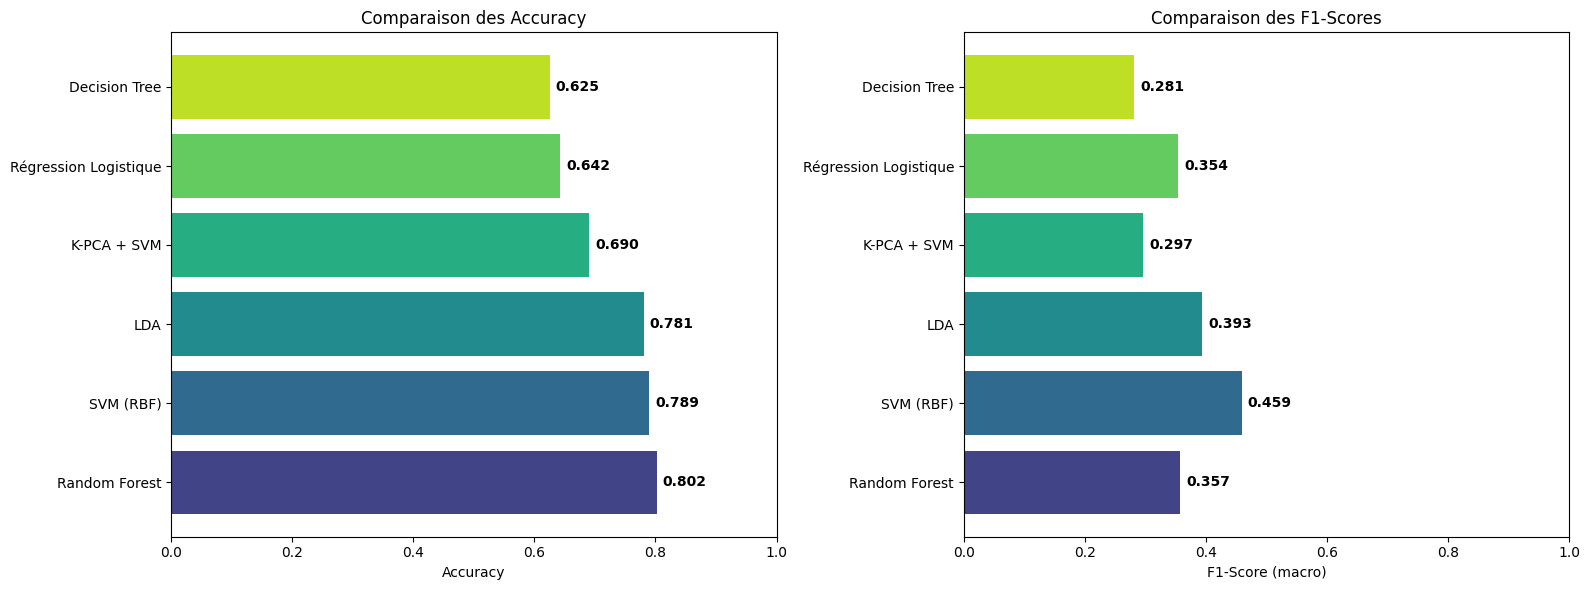

In [65]:
### Comparaison Méthodes

results = pd.DataFrame({
    'Modèle': ['SVM (RBF)', 'Random Forest', 'Decision Tree', 
               'K-PCA + SVM', 'LDA', 'Régression Logistique'],
    'Accuracy': [acc_svm, acc_rf, acc_dt, acc_kpca, acc_lda, acc_lr],
    'F1-Score (macro)': [
        f1_score(y_val, y_pred_svm, average='macro', zero_division=0),
        f1_score(y_val, y_pred_rf, average='macro', zero_division=0),
        f1_score(y_val, y_pred_dt, average='macro', zero_division=0),
        f1_score(y_val, y_pred_kpca, average='macro', zero_division=0),
        f1_score(y_val, y_pred_lda, average='macro', zero_division=0),
        f1_score(y_val, y_pred_lr, average='macro', zero_division=0),
    ]
})

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results)))
bars = axes[0].barh(results['Modèle'], results['Accuracy'], color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparaison des Accuracy')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, results['Accuracy']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', va='center', fontweight='bold')

bars2 = axes[1].barh(results['Modèle'], results['F1-Score (macro)'], color=colors)
axes[1].set_xlabel('F1-Score (macro)')
axes[1].set_title('Comparaison des F1-Scores')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, results['F1-Score (macro)']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

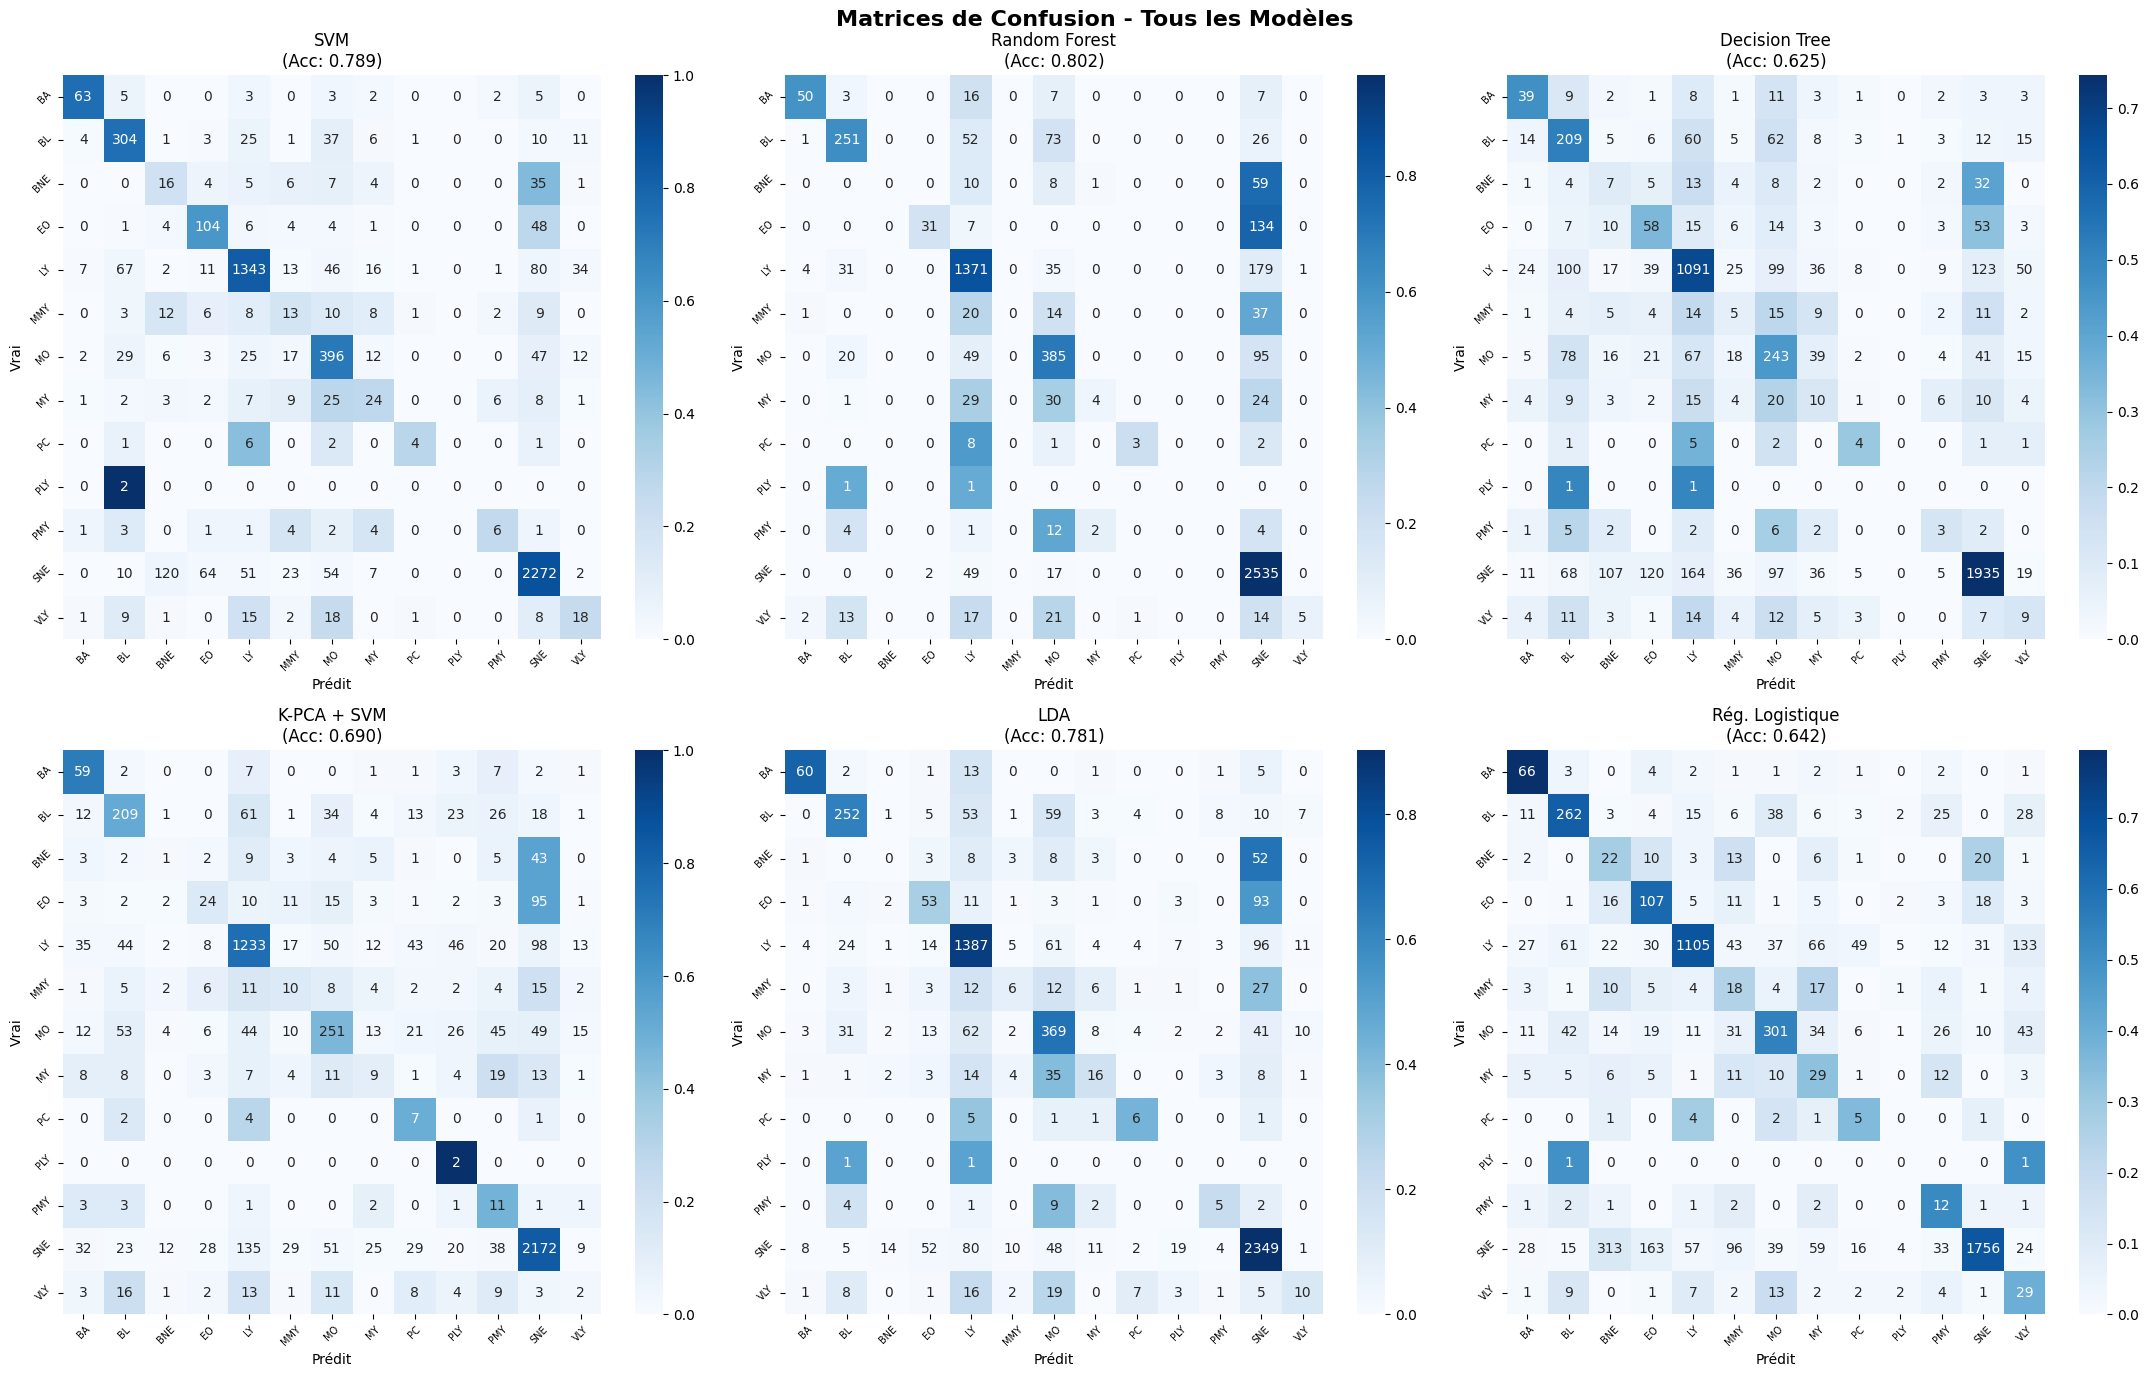

In [66]:
### Matrice de confusion 
predictions = {
    'SVM': y_pred_svm,
    'Random Forest': y_pred_rf,
    'Decision Tree': y_pred_dt,
    'K-PCA + SVM': y_pred_kpca,
    'LDA': y_pred_lda,
    'Rég. Logistique': y_pred_lr
}

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar=True)
    axes[idx].set_title(f'{name}\n(Acc: {accuracy_score(y_val, y_pred):.3f})', fontsize=12)
    axes[idx].set_ylabel('Vrai')
    axes[idx].set_xlabel('Prédit')
    axes[idx].tick_params(axis='both', labelsize=7, rotation=45)

plt.suptitle("Matrices de Confusion - Tous les Modèles", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

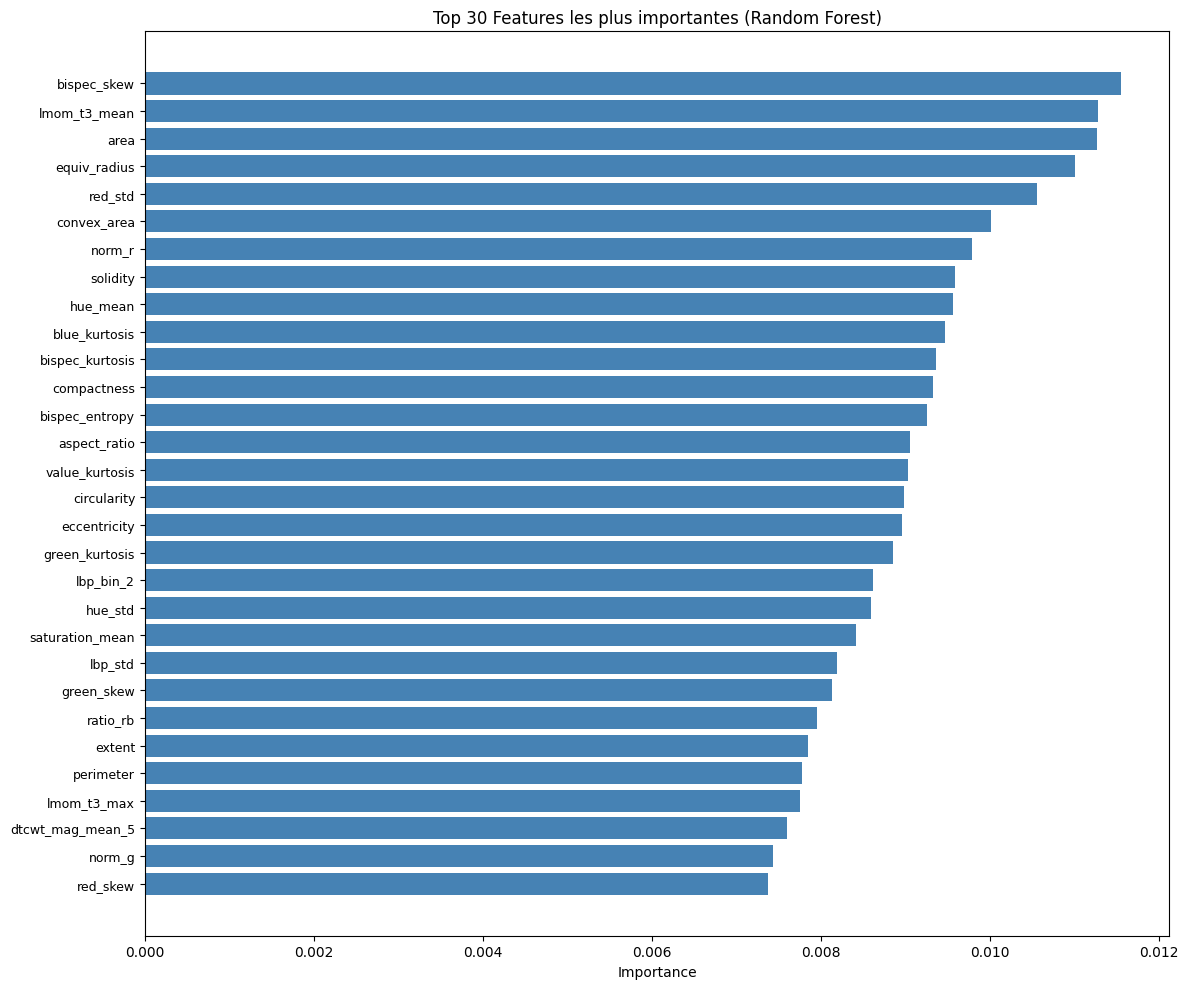


Top 15 features :
        feature  importance
    bispec_skew    0.011542
   lmom_t3_mean    0.011275
           area    0.011268
   equiv_radius    0.011005
        red_std    0.010558
    convex_area    0.010004
         norm_r    0.009783
       solidity    0.009589
       hue_mean    0.009556
  blue_kurtosis    0.009466
bispec_kurtosis    0.009359
    compactness    0.009317
 bispec_entropy    0.009253
   aspect_ratio    0.009050
 value_kurtosis    0.009022
Validation croisée (5-fold stratifié) :


In [ ]:
### Comparaison features

feature_importance = pd.DataFrame({
    'feature': X_df.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 30
fig, ax = plt.subplots(figsize=(12, 10))
top_features = feature_importance.head(top_n)
ax.barh(range(top_n), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Features les plus importantes (Random Forest)')
plt.tight_layout()
plt.show()

print("\nTop 15 features :")
print(feature_importance.head(15).to_string(index=False))


### Cross Validation

print("Validation croisée (5-fold stratifié) :")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, class_weight='balanced', random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'Rég. Logistique': LogisticRegression(max_iter=2000, multi_class='multinomial', class_weight='balanced', random_state=42),
}

cv_results = {}
X_all_scaled = scaler.fit_transform(X_df.values)

for name, model in models_cv.items():
    scores = cross_val_score(model, X_all_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:25s} : {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:

def process_single_image_test(img_id, img_dir):
    img_path = os.path.join(img_dir, f"{img_id}")
    if not os.path.exists(img_path):
        return None, img_id, "not_found"
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, img_id, "none"
        feats = extract_all_features(img)
        return feats, img_id, None
    except Exception as e:
        return None, img_id, str(e)

results_test = Parallel(n_jobs=-1)(
    delayed(process_single_image_test)(row[test_df.columns[0]], TEST_DIR)
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test extraction")
)

test_features_list = []
test_ids_final = []
test_errors = []

for feats, img_id, err in results_test:
    if err is not None:
        test_errors.append(img_id)
    else:
        test_features_list.append(feats)
        test_ids_final.append(img_id)

X_test_df = pd.DataFrame(test_features_list)
X_test_df.fillna(0, inplace=True)
X_test_df.replace([np.inf, -np.inf], 0, inplace=True)

missing_cols = set(X_df.columns) - set(X_test_df.columns)
for col in missing_cols:
    X_test_df[col] = 0
X_test_df = X_test_df[X_df.columns]

print(f"\nTest extraction terminée : {len(X_test_df)} images")
print(f"Erreurs : {len(test_errors)}")


print("\nEntraînement du modèle final sur toutes les données train...")

best_model_name = results.iloc[0]['Modèle']
print(f"Meilleur modèle : {best_model_name}")

final_scaler = StandardScaler()
X_all_scaled_final = final_scaler.fit_transform(X_df.values)
X_test_scaled_final = final_scaler.transform(X_test_df.values)

final_model = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
final_model.fit(X_all_scaled_final, y)

y_test_pred = final_model.predict(X_test_scaled_final)
y_test_labels = le.inverse_transform(y_test_pred)


submission = pd.DataFrame({
    test_df.columns[0]: test_ids_final,
    label_col: y_test_labels
})

submission.to_csv("submission.csv", index=False)
print(f"\n Fichier de soumission créé : submission.csv")
print(f"   Nombre de prédictions : {len(submission)}")
print(f"\nDistribution des prédictions :")
print(submission[label_col].value_counts())
print(f"\nAperçu :")
print(submission.head(10))


Extraction des features sur le dataset de test...


Test extraction:   0%|          | 0/9634 [00:00<?, ?it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Test extraction:   0%|          | 16/9634 [00:00<01:58, 81.24it/s]/Users/agshayn/Desktop/cours/2A/IMA/4IM05/projet_kaggle/.venv/lib/python3.9/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
Test extraction:   0%|          | 32/9634 [00:00<01:56, 82.73it/s]Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
Corrupt JPEG data: 27 extraneous bytes before marker 0xdb
/Users/agshayn/Desktop/cours/2A/IMA/4IM05/projet_kaggle/.venv/lib/python3.9/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
Test extraction:   0%|          | 48/9634 [00:00<02:44, 58.20it/s]Corrupt JPE


✅ Test extraction terminée : 9634 images
   Erreurs : 0

Entraînement du modèle final sur toutes les données train...
Meilleur modèle : Random Forest

✅ Fichier de soumission créé : submission.csv
   Nombre de prédictions : 9634

Distribution des prédictions :
label
SNE    4156
LY     2575
MO      880
BL      719
EO      353
BNE     300
MY      154
BA      153
MMY     150
VLY     146
PMY      34
PC       13
PLY       1
Name: count, dtype: int64

Aperçu :
               ID label
0  test_00000.png    LY
1  test_00001.png    BL
2  test_00002.png   SNE
3  test_00003.png   SNE
4  test_00004.png    LY
5  test_00005.png    LY
6  test_00006.png   SNE
7  test_00007.png    LY
8  test_00008.png    EO
9  test_00009.png    BA
